In [29]:
import numpy as np, pandas as pd, tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML/Alcohol_Sales.csv')
data = df['S4248SM144NCEN'].values.reshape(-1,1)

In [30]:
# 2. 정규화
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [31]:
# 3. 시퀀스 생성
window = 12   # 최근 12개월 → 다음달 예측
X, y = [], []
for i in range(len(data)-window):
    X.append(data[i:i+window])
    y.append(data[i+window])
X, y = np.array(X), np.array(y)



print(f"X shape: {X.shape}") # (샘플 수, 12, 1)
print(f"y shape: {y.shape}")

X shape: (313, 12, 1)
y shape: (313, 1)


In [32]:
# 4. 훈련/테스트 데이터 분리 (시계열 데이터는 순서대로 분리해야 함)
split_ratio = 0.8 # 80%를 훈련 데이터로 사용
split_point = int(len(X) * split_ratio)

# 순서대로 데이터를 자름
X_train, y_train = X[:split_point], y[:split_point]
X_test, y_test = X[split_point:], y[split_point:]

# 데이터 형태 확인
print(f"X_train shape: {X_train.shape}") # (샘플 수, 12, 1)
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (250, 12, 1)
y_train shape: (250, 1)
X_test shape: (63, 12, 1)
y_test shape: (63, 1)


In [33]:
# RNN 모델
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=(window,1)),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [34]:
# 모델 컴파일
model.compile(optimizer='adam', loss='mse')

In [35]:
# 모델 학습
history1 = model.fit(X_train, y_train,
                      epochs=100,
                      batch_size=32,
                      validation_data=(X_test, y_test),
                      verbose=1)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0957 - val_loss: 0.0229
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0203 - val_loss: 0.1041
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0102 - val_loss: 0.0512
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0051 - val_loss: 0.0245
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0046 - val_loss: 0.0377
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0027 - val_loss: 0.0267
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0025 - val_loss: 0.0155
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0020 - val_loss: 0.0173
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0017 - val_loss: 0.0168
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0017 - val_loss: 0.0173
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0014 - val_loss: 0.0166
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0014 - val_lo

In [36]:
# 모델 1 예측 및 MSE 계산
y_pred1 = model.predict(X_test)
mse1 = mean_squared_error(y_test, y_pred1)
print(f"\n모델 RNN (SimpleRNN) 정규화 MSE: {mse1:.8f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step

모델 RNN (SimpleRNN) 정규화 MSE: 0.00567764


In [37]:
# 실제 값 스케일로 되돌리기
y_test_inv = scaler.inverse_transform(y_test)
y_pred1_inv = scaler.inverse_transform(y_pred1)

In [38]:
real_mse1 = mean_squared_error(y_test_inv, y_pred1_inv)
print(f"모델 RNN (SimpleRNN) 실제 스케일 MSE: {real_mse1:.2f}")
print(f"모델 RNN (SimpleRNN) 실제 스케일 RMSE: {np.sqrt(real_mse1):.2f}")

모델 RNN (SimpleRNN) 실제 스케일 MSE: 883302.38
모델 RNN (SimpleRNN) 실제 스케일 RMSE: 939.84


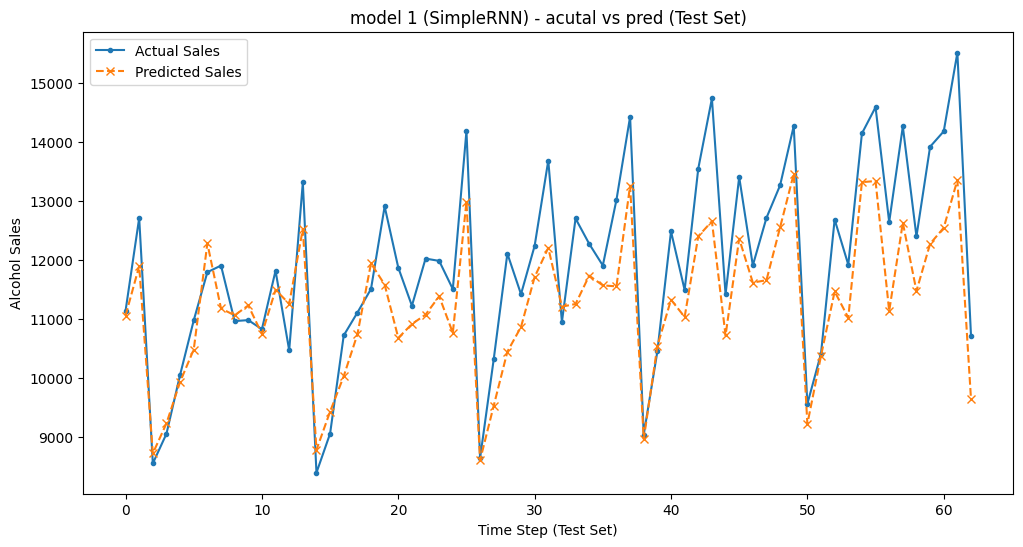

In [39]:
plt.figure(figsize=(12, 6))
plt.title('model 1 (SimpleRNN) - acutal vs pred (Test Set)')
# y_test_inv (실제값)는 이전에 scaler로 변환해 둔 변수입니다.
plt.plot(y_test_inv, label='Actual Sales', marker='.')
# y_pred1_inv (모델1 예측값)도 이전에 변환해 둔 변수입니다.
plt.plot(y_pred1_inv, label='Predicted Sales', marker='x', linestyle='--')
plt.legend()
plt.xlabel('Time Step (Test Set)')
plt.ylabel('Alcohol Sales')
plt.show()

In [40]:
# 4. LSTM 모델
model2 = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(window,1)),
    tf.keras.layers.Dense(1)
])
model2.compile(optimizer='adam', loss='mse')

# 모델 학습
history2 = model2.fit(X_train, y_train,
                      epochs=100,
                      batch_size=16,
                      validation_data=(X_test, y_test),
                      verbose=1)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.1185 - val_loss: 0.0206
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0158 - val_loss: 0.0516
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0100 - val_loss: 0.0184
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0081 - val_loss: 0.0173
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0055 - val_loss: 0.0153
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0053 - val_loss: 0.0150
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0053 - val_loss: 0.0173
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0040 - val_loss: 0.0144
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0048 - val_loss: 0.0146
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0048 - val_loss: 0.0150
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0052 - val_loss: 0.0146
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0047 - val_

In [42]:
# 모델 2 예측 및 MSE 계산
y_pred2 = model2.predict(X_test)
mse2 = mean_squared_error(y_test, y_pred2)
print(f"\n모델 2 (LSTM) 정규화 MSE: {mse2:.8f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

모델 2 (LSTM) 정규화 MSE: 0.00955222


In [43]:
# 실제 값 스케일로 되돌리기
y_pred2_inv = scaler.inverse_transform(y_pred2)

In [44]:
real_mse2 = mean_squared_error(y_test_inv, y_pred2_inv)
print(f"모델 2 (LSTM) 실제 스케일 MSE: {real_mse2:.2f}")
print(f"모델 2 (LSTM) 실제 스케일 RMSE: {np.sqrt(real_mse2):.2f}")

모델 2 (LSTM) 실제 스케일 MSE: 1486093.06
모델 2 (LSTM) 실제 스케일 RMSE: 1219.05


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


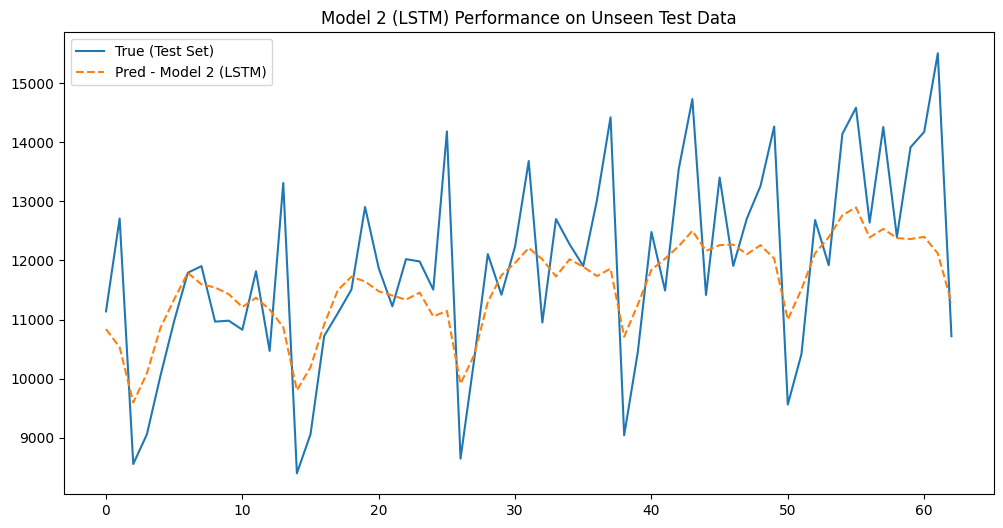

In [45]:
# 1. 'model2' (LSTM)로 예측을 수행합니다.
pred_test_2 = model2.predict(X_test)

# 2. 실제 테스트 정답인 'y_test'와 예측값 'pred_test_2'를 비교합니다.
y_test_inv = scaler.inverse_transform(y_test)
pred_test_inv_2 = scaler.inverse_transform(pred_test_2)


# 3. 모델 2의 테스트셋 결과만 시각화합니다.
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='True (Test Set)')
plt.plot(pred_test_inv_2, label='Pred - Model 2 (LSTM)', linestyle='--') # 모델 2의 예측값 사용
plt.title('Model 2 (LSTM) Performance on Unseen Test Data')
plt.legend()
plt.show()